In [ ]:
import numpy as np
from pycbc.types import load_frequencyseries
from pycbc.psd import interpolate

from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm 
plt.style.use('../paper.mplstyle')

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
input_data = '../datasets/LDC2_sangria_hm_training.hdf' # The Sangria dataset

In [3]:
# days before merger to use as cutoffs
cutoff_days = [0.5, 1, 4, 7, 14]

In [4]:
norm = mcolors.LogNorm(vmin=min(cutoff_days), vmax=max(cutoff_days))
cmap = cm.get_cmap('rainbow')
sm = cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

time_before_colors = {
    time_before: sm.to_rgba(time_before)
    for time_before in cutoff_days
}
time_before_colors[0] = 'k'

/local/gareth.cabourndavies/ipykernel_559995/2762826291.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow')


In [5]:

hc_all = {}
# lets just use mbhb 4 as an example
signals = range(15)
for sig_num in signals:
    print(f'Signal {sig_num}')


    # save the characteristic strain psd
    h_c_fs = load_frequencyseries(
        f'characteristic_strain/characteristic_strain_{sig_num}_full.txt',
    )
    h_c = h_c_fs.data
    freqs = h_c_fs.sample_frequencies

    hc_all[sig_num] = {
        0: h_c
    }

    for i, days in enumerate(cutoff_days):
        print(f'{days} days before merger')

        hc_all[sig_num][days] = load_frequencyseries(
            f'characteristic_strain/characteristic_strain_{sig_num}_{days}.txt',
        )

Signal 0


0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 1
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 2
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 3
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 4
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 5
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 6
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 7
0.5 days before merger
1 days before merger
4 days before merger
7 days before merger
14 days before merger
Signal 8
0.5 days before merger
1 days before merger
4 days before merger

Lets compute the expected SNR from characteristic strain for each signal and each time before merger

In [6]:
# Typical PSD
psd = load_frequencyseries('model_AE_SMOOTHED_PSD.txt')

# interpolate the PSD so that it matches the signal PSD
psd = interpolate(psd, h_c_fs.delta_f)
psd[0] = 0
psd.resize(len(h_c_fs))


/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


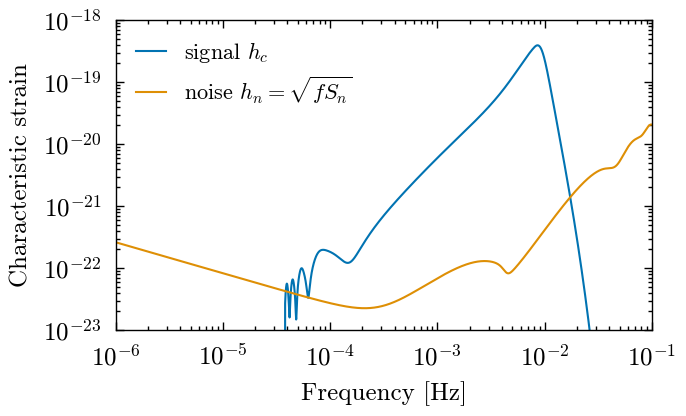

In [7]:
hn = np.sqrt(freqs * psd)  # characteristic noise curve

fig, ax  = plt.subplots(1)
print
ax.loglog(freqs, hc_all[4][0], label='signal $h_c$')
ax.loglog(freqs, hn, label='noise $h_n = \sqrt{f S_n}$')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Characteristic strain')
ax.set_ylim(1e-23, 1e-18)
ax.set_xlim(1e-6, 0.1)
ax.legend()

In [ ]:
table_str = """\\begin{tabular}{|c|c|ccccc|}
\\hline
\\multirow{2}{*}{Signal Number }& \multicolumn{6}{c|}{Expected SNR} \\\\
\\cline{2-7}
  & Full Signal & 0.5 & 1 & 4 & 7 & 14 \\\\
\\hline
"""
for sig_num in signals:
    table_row = f"{sig_num}"
    for days in [0] + cutoff_days:
        h_c_tbefore  = hc_all[sig_num][days]
        valid = h_c_tbefore > 0
        snr2 = np.trapezoid((h_c_tbefore[valid] / hn[valid])**2, np.log(freqs[valid]))
        snr = np.sqrt(snr2)
        table_row += f" & {snr:.2f}"
    table_row += " \\\\\n"
    table_str += table_row
table_str += """\\hline
\\end{tabular}"""

with open("../paper/characteristic_strain_table.tex", 'w') as table_file:
    table_file.write(table_str)

    